# modeling_2 — EfficientNet-B0 base_224x224: Re-treino e Análise Completa

Replica o experimento **base_224x224** do `04_modeling.ipynb` (melhor AUC geral: 0.9039)
e extrai métricas detalhadas além do benchmark original.

**Configuração replicada**
- Modelo: `EfficientNet-B0` com pré-treino ImageNet
- Imagens: 224×224, **sem augmentation online**
- Split: 70/15/15, balanceamento apenas no treino (ratio 1:3 mel:non-mel)
- Critério clínico: sensibilidade ≥ 95% (threshold escolhido na validação)

**Métricas adicionais**
- Contagem total de predições por classe
- Matriz de confusão visual
- Classification report completo
- Distribuição das probabilidades (mel vs non-mel)
- Curva ROC e Precision-Recall
- Análise de trade-off por threshold
- Visualização de falsos positivos e falsos negativos

In [55]:
import json
import random
import warnings
from pathlib import Path

import cv2
import matplotlib
from IPython import get_ipython

ipython = get_ipython()
if ipython is None or ipython.__class__.__name__ != "ZMQInteractiveShell":
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn as nn
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

print(f"torch  : {torch.__version__}")
print(f"timm   : {timm.__version__}")
print(f"CUDA   : {torch.cuda.is_available()}")
print(f"MPS    : {torch.backends.mps.is_available()}")

torch  : 2.11.0
timm   : 1.0.26
CUDA   : False
MPS    : True


## 1. Configuração

In [56]:
def resolve_repo_root() -> Path:
    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidate in candidates:
        if (candidate / "data" / "metadata.csv").exists() and (candidate / "docs").exists():
            return candidate
    raise FileNotFoundError("Raiz do repositório não encontrada.")


ROOT_DIR = resolve_repo_root()
DATA_DIR = ROOT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
TREATED_MANIFEST = PROCESSED_DIR / "treated_manifest.csv"
FIG_DIR = ROOT_DIR / "outputs" / "figures" / "modeling_2"
MODEL_DIR = ROOT_DIR / "outputs" / "models" / "model_comparison"
SAVED_MODEL_PATH = MODEL_DIR / "efficientnet_b0_base_224x224.pt"

FIG_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparâmetros idênticos ao 04_modeling base_224x224
SEED = 42
IMAGE_SIZE = 224
AUGMENT = True
BATCH_SIZE = 16
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
NON_MELANOMA_TO_MELANOMA_RATIO = 3.0
HARD_NEGATIVE_LABEL = "NV"
HARD_NEGATIVE_MULTIPLIER = 2.0
EFFICIENTNET_MODEL_NAME = "efficientnet_b0"
LR = 1e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 16
PATIENCE = 4
MELANOMA_RECALL_TARGET = 0.85

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

PIN_MEMORY = DEVICE.type == "cuda"
print(f"Device            : {DEVICE}")
print(f"Modelo salvo em   : {SAVED_MODEL_PATH}")
print(f"Modelo existe     : {SAVED_MODEL_PATH.exists()}")

Device            : mps
Modelo salvo em   : /Users/eduardoyaginuma/Documents/Repositorios/insper/skin-cancer-images-segmentation/outputs/models/model_comparison/efficientnet_b0_base_224x224.pt
Modelo existe     : True


## 2. Preparação dos dados

Split e balanceamento idênticos ao `04_modeling.ipynb` para garantir comparabilidade.

In [57]:
treated_df = pd.read_csv(TREATED_MANIFEST)

train_full_df, temp_df = train_test_split(
    treated_df,
    test_size=1 - TRAIN_RATIO,
    stratify=treated_df["binary_label"],
    random_state=SEED,
)
relative_test = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test,
    stratify=temp_df["binary_label"],
    random_state=SEED,
)

melanoma_train = train_full_df[train_full_df["binary_label"] == 1].copy()
non_mel_train  = train_full_df[train_full_df["binary_label"] == 0].copy()
target_non_mel = min(
    len(non_mel_train),
    int(round(len(melanoma_train) * NON_MELANOMA_TO_MELANOMA_RATIO)),
)
if target_non_mel < len(non_mel_train):
    non_mel_sampled, _ = train_test_split(
        non_mel_train,
        train_size=target_non_mel,
        stratify=non_mel_train["label"],
        random_state=SEED,
    )
else:
    non_mel_sampled = non_mel_train.copy()

train_df = (
    pd.concat([melanoma_train, non_mel_sampled])
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)
val_df  = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

summary = pd.DataFrame([
    {
        "split": s,
        "melanoma": int((f["binary_label"] == 1).sum()),
        "nao_melanoma": int((f["binary_label"] == 0).sum()),
        "total": len(f),
    }
    for s, f in [("train (balanceado)", train_df), ("val", val_df), ("test", test_df)]
])
display(summary)

,split,melanoma,nao_melanoma,total
0,train (balanceado),779,2337,3116
1,val,167,1335,1502
2,test,167,1336,1503


## 3. Dataset, DataLoader e estatísticas de normalização

In [58]:
def compute_norm_stats(manifest: pd.DataFrame, image_size: int, sample_size: int = 512) -> dict:
    sample = manifest.sample(n=min(sample_size, len(manifest)), random_state=SEED)
    ch_sum = np.zeros(3, dtype=np.float64)
    ch_sq  = np.zeros(3, dtype=np.float64)
    n_pixels = 0
    for row in sample.itertuples():
        img = cv2.imread(str(row.export_path), cv2.IMREAD_COLOR)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (image_size, image_size), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0
        px = img.reshape(-1, 3)
        ch_sum   += px.sum(0)
        ch_sq    += (px ** 2).sum(0)
        n_pixels += len(px)
    mean = (ch_sum / n_pixels).round(6).tolist()
    std  = np.sqrt(np.maximum(ch_sq / n_pixels - (ch_sum / n_pixels) ** 2, 1e-12)).round(6).tolist()
    return {"mean": mean, "std": std}


print("Calculando estatísticas de normalização...")
norm = compute_norm_stats(train_df, IMAGE_SIZE)
NORM_MEAN, NORM_STD = norm["mean"], norm["std"]
print(f"  mean={NORM_MEAN}")
print(f"  std ={NORM_STD}")


def load_rgb_array(path: str | Path, size: int) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    return np.ascontiguousarray(img)


def to_tensor(img_np: np.ndarray, mean: list, std: list) -> torch.Tensor:
    t = torch.from_numpy(img_np.transpose(2, 0, 1)).float().div(255.0)
    m = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
    s = torch.tensor(std,  dtype=torch.float32).view(3, 1, 1)
    return (t - m) / s


class SkinDataset(Dataset):
    def __init__(self, manifest: pd.DataFrame, augment: bool = False):
        self.records = manifest.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        img = load_rgb_array(row["export_path"], IMAGE_SIZE)
        # float [0,1] tensor antes da normalização para permitir color jitter
        t = torch.from_numpy(img.transpose(2, 0, 1)).float().div(255.0)
        if self.augment:
            import torchvision.transforms.functional as TF
            if random.random() < 0.5:
                t = TF.hflip(t)
            if random.random() < 0.5:
                t = TF.vflip(t)
            t = TF.rotate(t, random.uniform(-180, 180))
            t = TF.adjust_brightness(t, 1.0 + random.uniform(-0.2, 0.2))
            t = TF.adjust_contrast(t,   1.0 + random.uniform(-0.2, 0.2))
            t = TF.adjust_saturation(t, 1.0 + random.uniform(-0.2, 0.2))
            t = t.clamp(0.0, 1.0)
        m = torch.tensor(NORM_MEAN, dtype=torch.float32).view(3, 1, 1)
        s = torch.tensor(NORM_STD,  dtype=torch.float32).view(3, 1, 1)
        t = (t - m) / s
        lbl = torch.tensor(int(row["binary_label"]), dtype=torch.float32)
        return t, lbl


def build_weighted_sampler(manifest: pd.DataFrame) -> WeightedRandomSampler:
    pos = max(int((manifest["binary_label"] == 1).sum()), 1)
    neg = max(int((manifest["binary_label"] == 0).sum()), 1)
    pw  = neg / pos
    weights = []
    for r in manifest.itertuples():
        if r.binary_label == 1:
            mult = HARD_NEGATIVE_MULTIPLIER if getattr(r, "label", None) == HARD_NEGATIVE_LABEL else 1.0
            weights.append(pw * mult)
        else:
            weights.append(1.0)
    return WeightedRandomSampler(torch.DoubleTensor(weights), len(weights), replacement=True)


train_ds = SkinDataset(train_df, augment=AUGMENT)
val_ds   = SkinDataset(val_df,   augment=False)
test_ds  = SkinDataset(test_df,  augment=False)

sampler = build_weighted_sampler(train_df)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=0, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=0, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=0, pin_memory=PIN_MEMORY)

print(f"Batches — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)}")

Calculando estatísticas de normalização...
  mean=[0.752149, 0.523136, 0.545339]
  std =[0.14574, 0.164336, 0.184771]
Batches — train:195  val:94  test:94


## 4. Treino (ou carga do modelo salvo)

Por padrão carrega o modelo já treinado em `04_modeling.ipynb`.  
Mude `FORCE_RETRAIN = True` para re-treinar do zero.

In [59]:
def build_model(pretrained: bool = True) -> nn.Module:
    try:
        return timm.create_model(EFFICIENTNET_MODEL_NAME, pretrained=pretrained, num_classes=1)
    except Exception:
        print("Pretrained falhou — usando random init.")
        return timm.create_model(EFFICIENTNET_MODEL_NAME, pretrained=False, num_classes=1)


def run_epoch_train(model, loader, criterion, optimizer):
    model.train()
    total_loss, probs_all, labels_all = 0.0, [], []
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss   = criterion(logits, lbls)
        loss.backward()
        optimizer.step()
        total_loss  += loss.item() * len(lbls)
        probs_all.extend(torch.sigmoid(logits).detach().cpu().tolist())
        labels_all.extend(lbls.cpu().tolist())
    auc_sc = roc_auc_score(labels_all, probs_all) if len(set(labels_all)) > 1 else 0.0
    return {"loss": total_loss / max(len(labels_all), 1), "auc": auc_sc}


@torch.no_grad()
def run_epoch_eval(model, loader, criterion):
    model.eval()
    total_loss, probs_all, labels_all = 0.0, [], []
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        logits = model(imgs).squeeze(1)
        loss   = criterion(logits, lbls)
        total_loss  += loss.item() * len(lbls)
        probs_all.extend(torch.sigmoid(logits).cpu().tolist())
        labels_all.extend(lbls.cpu().tolist())
    auc_sc = roc_auc_score(labels_all, probs_all) if len(set(labels_all)) > 1 else 0.0
    return {"loss": total_loss / max(len(labels_all), 1), "auc": auc_sc,
            "probs": probs_all, "labels": labels_all}


FORCE_RETRAIN = True  # True para re-treinar do zero

criterion = nn.BCEWithLogitsLoss()

history = None

if SAVED_MODEL_PATH.exists() and not FORCE_RETRAIN:
    print(f"Carregando modelo salvo de:\n  {SAVED_MODEL_PATH}")
    model = build_model(pretrained=False)
    model.load_state_dict(torch.load(SAVED_MODEL_PATH, map_location="cpu"))
    model = model.to(DEVICE)
    print("Modelo carregado com sucesso.")
else:
    print("Re-treinando do zero...")
    model = build_model(pretrained=True).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    history = {"train_loss": [], "train_auc": [], "val_loss": [], "val_auc": []}
    best_val_auc, best_state, patience_counter = -float("inf"), None, 0

    for epoch in range(1, EPOCHS + 1):
        tr = run_epoch_train(model, train_loader, criterion, optimizer)
        vl = run_epoch_eval(model, val_loader, criterion)
        scheduler.step()
        history["train_loss"].append(tr["loss"])
        history["train_auc"].append(tr["auc"])
        history["val_loss"].append(vl["loss"])
        history["val_auc"].append(vl["auc"])
        improved = vl["auc"] > best_val_auc
        tag = " <<<" if improved else ""
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | train loss={tr['loss']:.4f} auc={tr['auc']:.4f}"
            f" | val loss={vl['loss']:.4f} auc={vl['auc']:.4f}{tag}"
        )
        if improved:
            best_val_auc = vl["auc"]
            best_state   = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping na época {epoch}.")
                break

    model.load_state_dict(best_state)
    save_path = MODEL_DIR / "efficientnet_b0_base_224x224_calibrated.pt"
    torch.save(best_state, save_path)
    print(f"Modelo salvo em {save_path}")

Re-treinando do zero...
Epoch 01/16 | train loss=1.4374 auc=0.7484 | val loss=0.9567 auc=0.7792 <<<
Epoch 02/16 | train loss=0.9679 auc=0.8114 | val loss=1.6468 auc=0.7737
Epoch 03/16 | train loss=0.8775 auc=0.8234 | val loss=0.7769 auc=0.8207 <<<
Epoch 04/16 | train loss=0.7190 auc=0.8533 | val loss=0.7188 auc=0.8374 <<<
Epoch 05/16 | train loss=0.5677 auc=0.8885 | val loss=0.4624 auc=0.8485 <<<
Epoch 06/16 | train loss=0.4897 auc=0.9022 | val loss=0.4569 auc=0.8510 <<<
Epoch 07/16 | train loss=0.4296 auc=0.9213 | val loss=0.5821 auc=0.8739 <<<
Epoch 08/16 | train loss=0.4428 auc=0.9140 | val loss=0.5170 auc=0.8679
Epoch 09/16 | train loss=0.3629 auc=0.9331 | val loss=0.4556 auc=0.8888 <<<
Epoch 10/16 | train loss=0.3400 auc=0.9402 | val loss=0.4727 auc=0.8843
Epoch 11/16 | train loss=0.3043 auc=0.9483 | val loss=0.5121 auc=0.8893 <<<
Epoch 12/16 | train loss=0.2821 auc=0.9540 | val loss=0.4695 auc=0.8884
Epoch 13/16 | train loss=0.2721 auc=0.9573 | val loss=0.4671 auc=0.8903 <<<
Epoc

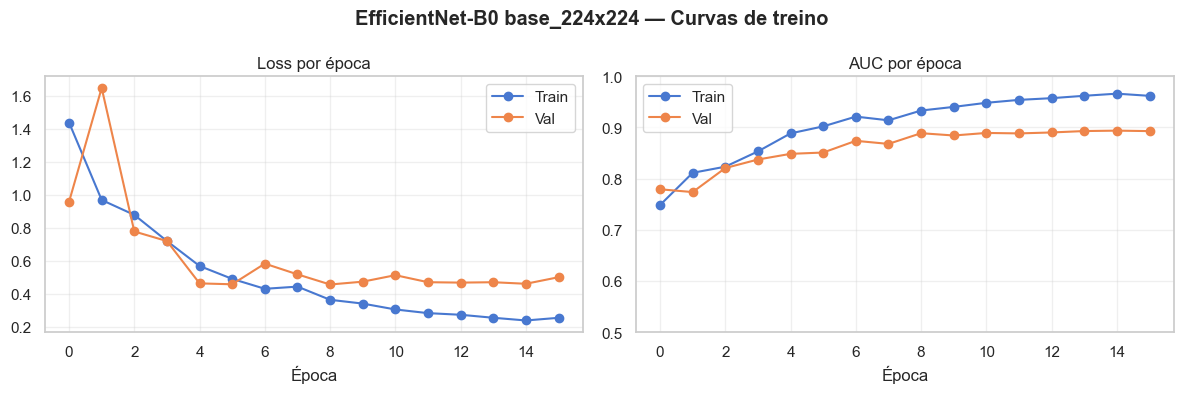

In [60]:
if history is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train", marker="o")
    axes[0].plot(history["val_loss"],   label="Val",   marker="o")
    axes[0].set_title("Loss por época")
    axes[0].set_xlabel("Época")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["train_auc"], label="Train", marker="o")
    axes[1].plot(history["val_auc"],   label="Val",   marker="o")
    axes[1].set_title("AUC por época")
    axes[1].set_xlabel("Época")
    axes[1].set_ylim(0.5, 1.0)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle("EfficientNet-B0 base_224x224 — Curvas de treino", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Modelo carregado de arquivo — curvas de treino não disponíveis.")

## 5. Inferência e escolha do threshold clínico

O threshold é selecionado na **validação** buscando a maior especificidade entre os candidatos
que atingem sensibilidade ≥ 95%. Depois aplicado fixo no test set.

In [61]:
val_out  = run_epoch_eval(model, val_loader,  criterion)
test_out = run_epoch_eval(model, test_loader, criterion)

val_probs   = np.array(val_out["probs"])
val_labels  = np.array(val_out["labels"], dtype=int)
test_probs  = np.array(test_out["probs"])
test_labels = np.array(test_out["labels"], dtype=int)

print(f"Val  AUC: {roc_auc_score(val_labels,  val_probs):.4f}")
print(f"Test AUC: {roc_auc_score(test_labels, test_probs):.4f}")


def choose_threshold(probs: np.ndarray, labels: np.ndarray, target_recall: float = 0.95):
    """Maior especificidade com sensibilidade >= target_recall (avaliado na validação)."""
    candidates = np.sort(np.unique(np.round(np.concatenate(([0.0], probs, [1.0])), 6)))
    rows = []
    for t in candidates:
        preds = (probs >= t).astype(int)
        tn_, fp_, fn_, tp_ = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
        sens = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0.0
        spec = tn_ / (tn_ + fp_) if (tn_ + fp_) > 0 else 0.0
        rows.append({"threshold": t, "sensitivity": sens, "specificity": spec})
    tbl = pd.DataFrame(rows)
    feasible = tbl[tbl["sensitivity"] >= target_recall]
    if len(feasible) > 0:
        best = feasible.sort_values(["specificity", "threshold"], ascending=[False, True]).iloc[0]
        hit  = True
    else:
        best = tbl.sort_values(["sensitivity", "specificity"], ascending=[False, False]).iloc[0]
        hit  = False
    return float(best["threshold"]), hit, tbl


THRESHOLD, TARGET_HIT, THRESHOLD_TABLE = choose_threshold(val_probs, val_labels, MELANOMA_RECALL_TARGET)
print(f"\nThreshold escolhido (val) : {THRESHOLD:.4f}")
print(f"Target recall atingido    : {TARGET_HIT}")

Val  AUC: 0.8938
Test AUC: 0.9015

Threshold escolhido (val) : 0.2208
Target recall atingido    : True


## 6. Métricas detalhadas no test set

In [62]:
test_preds = (test_probs >= THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(test_labels, test_preds, labels=[0, 1]).ravel()

total     = len(test_labels)
n_mel     = int(test_labels.sum())
n_nonmel  = total - n_mel
pred_mel    = int(test_preds.sum())
pred_nonmel = total - pred_mel

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1          = f1_score(test_labels, test_preds, zero_division=0)
beta_sq = 4.0
f2 = (1 + beta_sq) * precision * sensitivity / max(beta_sq * precision + sensitivity, 1e-12)
accuracy = (tp + tn) / total
auc_test = roc_auc_score(test_labels, test_probs)

print("=" * 58)
print(f"  EfficientNet-B0 base_224x224 | Test set ({total} amostras)")
print("=" * 58)
print(f"  Threshold aplicado            : {THRESHOLD:.4f}")
print()
print("  --- Composição real do test set ---")
print(f"  Melanoma (real)               : {n_mel:>5}  ({n_mel/total*100:.1f}%)")
print(f"  Não-melanoma (real)           : {n_nonmel:>5}  ({n_nonmel/total*100:.1f}%)")
print()
print("  --- O que o modelo prediz ---")
print(f"  Predito como MELANOMA         : {pred_mel:>5}  ({pred_mel/total*100:.1f}%)")
print(f"  Predito como NÃO-MELANOMA     : {pred_nonmel:>5}  ({pred_nonmel/total*100:.1f}%)")
print()
print("  --- Detalhamento (matriz de confusão) ---")
print(f"  TP  mel correta               : {tp:>5}")
print(f"  TN  non-mel correta           : {tn:>5}")
print(f"  FP  non-mel → melanoma        : {fp:>5}  (falsos alarmes)")
print(f"  FN  mel → non-mel             : {fn:>5}  (melanomas perdidos!!)")
print()
print("  --- Métricas ---")
print(f"  AUC                           : {auc_test:.4f}")
print(f"  Sensibilidade (recall)        : {sensitivity:.4f}")
print(f"  Especificidade                : {specificity:.4f}")
print(f"  Precisão                      : {precision:.4f}")
print(f"  F1-score                      : {f1:.4f}")
print(f"  F2-score (peso recall)        : {f2:.4f}")
print(f"  Acurácia                      : {accuracy:.4f}")
print("=" * 58)

  EfficientNet-B0 base_224x224 | Test set (1503 amostras)
  Threshold aplicado            : 0.2208

  --- Composição real do test set ---
  Melanoma (real)               :   167  (11.1%)
  Não-melanoma (real)           :  1336  (88.9%)

  --- O que o modelo prediz ---
  Predito como MELANOMA         :   494  (32.9%)
  Predito como NÃO-MELANOMA     :  1009  (67.1%)

  --- Detalhamento (matriz de confusão) ---
  TP  mel correta               :   151
  TN  non-mel correta           :   993
  FP  non-mel → melanoma        :   343  (falsos alarmes)
  FN  mel → non-mel             :    16  (melanomas perdidos!!)

  --- Métricas ---
  AUC                           : 0.9015
  Sensibilidade (recall)        : 0.9042
  Especificidade                : 0.7433
  Precisão                      : 0.3057
  F1-score                      : 0.4569
  F2-score (peso recall)        : 0.6497
  Acurácia                      : 0.7611


In [63]:
print("Classification Report completo:")
print(classification_report(
    test_labels, test_preds,
    target_names=["Não-melanoma", "Melanoma"],
    digits=4,
))

Classification Report completo:
              precision    recall  f1-score   support

Não-melanoma     0.9841    0.7433    0.8469      1336
    Melanoma     0.3057    0.9042    0.4569       167

    accuracy                         0.7611      1503
   macro avg     0.6449    0.8237    0.6519      1503
weighted avg     0.9088    0.7611    0.8036      1503



## 7. Matriz de confusão visual

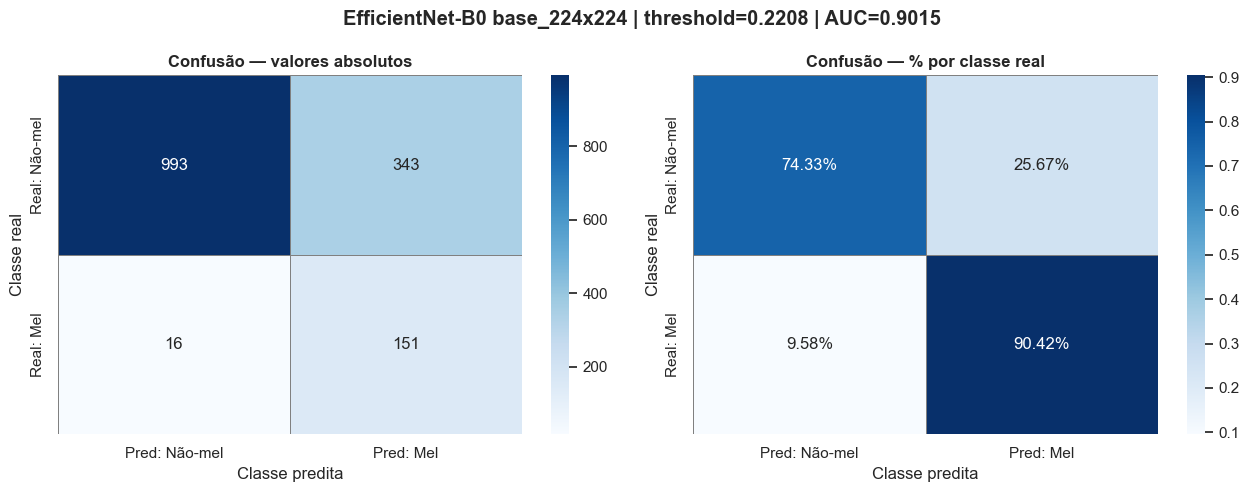

In [64]:
cm = confusion_matrix(test_labels, test_preds, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
    xticklabels=["Pred: Não-mel", "Pred: Mel"],
    yticklabels=["Real: Não-mel", "Real: Mel"],
    linewidths=0.5, linecolor="gray",
)
axes[0].set_title("Confusão — valores absolutos", fontweight="bold")
axes[0].set_ylabel("Classe real")
axes[0].set_xlabel("Classe predita")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt=".2%", cmap="Blues", ax=axes[1],
    xticklabels=["Pred: Não-mel", "Pred: Mel"],
    yticklabels=["Real: Não-mel", "Real: Mel"],
    linewidths=0.5, linecolor="gray",
)
axes[1].set_title("Confusão — % por classe real", fontweight="bold")
axes[1].set_ylabel("Classe real")
axes[1].set_xlabel("Classe predita")

plt.suptitle(
    f"EfficientNet-B0 base_224x224 | threshold={THRESHOLD:.4f} | AUC={auc_test:.4f}",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Curva ROC e Precision-Recall

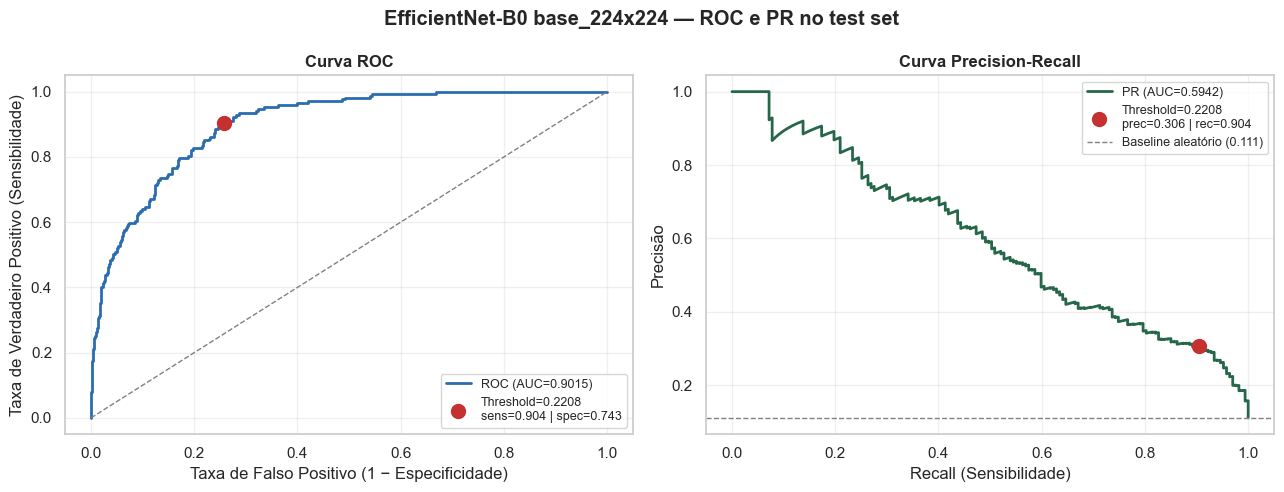

In [66]:
fpr_arr, tpr_arr, _ = roc_curve(test_labels, test_probs)
auc_roc = auc(fpr_arr, tpr_arr)

prec_arr, rec_arr, _ = precision_recall_curve(test_labels, test_probs)
auc_pr = auc(rec_arr, prec_arr)

# Ponto operacional no threshold escolhido
fpr_op = fp / (fp + tn) if (fp + tn) > 0 else 0.0
tpr_op = sensitivity

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr_arr, tpr_arr, color="#2b6cb0", linewidth=2,
             label=f"ROC (AUC={auc_roc:.4f})")
axes[0].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
axes[0].scatter([fpr_op], [tpr_op], color="#c53030", zorder=5, s=100,
                label=f"Threshold={THRESHOLD:.4f}\nsens={tpr_op:.3f} | spec={specificity:.3f}")
axes[0].set_xlabel("Taxa de Falso Positivo (1 − Especificidade)")
axes[0].set_ylabel("Taxa de Verdadeiro Positivo (Sensibilidade)")
axes[0].set_title("Curva ROC", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].plot(rec_arr, prec_arr, color="#276749", linewidth=2,
             label=f"PR (AUC={auc_pr:.4f})")
axes[1].scatter([sensitivity], [precision], color="#c53030", zorder=5, s=100,
                label=f"Threshold={THRESHOLD:.4f}\nprec={precision:.3f} | rec={sensitivity:.3f}")
baseline_pr = n_mel / total
axes[1].axhline(baseline_pr, color="gray", linestyle="--", linewidth=1,
                label=f"Baseline aleatório ({baseline_pr:.3f})")
axes[1].set_xlabel("Recall (Sensibilidade)")
axes[1].set_ylabel("Precisão")
axes[1].set_title("Curva Precision-Recall", fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("EfficientNet-B0 base_224x224 — ROC e PR no test set", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Trade-off por threshold

Como sensibilidade, especificidade, FN e volume de alertas variam conforme o threshold.

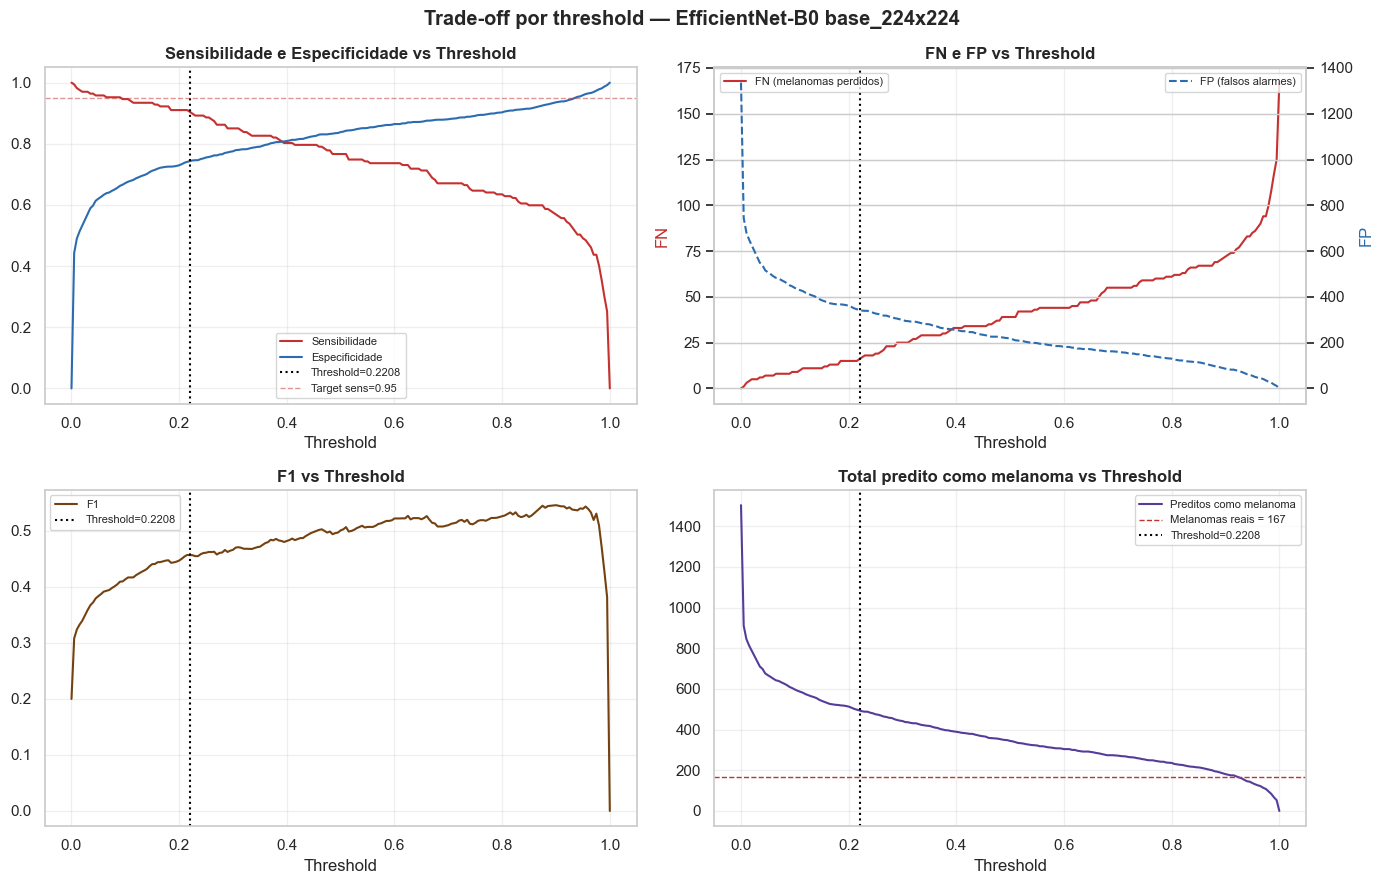

Referência rápida por threshold no test set:


,threshold,sensibilidade,especificidade,precisao,f1,fn,fp,pred_mel
0,0.000,1.0000,0.0000,0.1111,0.2000,0.0,1336.0,1503.0
1,0.005,0.9940,0.4431,0.1824,0.3083,1.0,744.0,910.0
2,0.010,0.9820,0.4903,0.1941,0.3241,3.0,681.0,845.0
3,0.050,0.9581,0.6205,0.2399,0.3837,7.0,507.0,667.0
4,0.100,0.9461,0.6714,0.2647,0.4136,9.0,439.0,597.0
5,0.200,0.9102,0.7298,0.2963,0.4471,15.0,361.0,513.0
6,0.300,0.8503,0.7754,0.3213,0.4663,25.0,300.0,442.0
7,0.400,0.8024,0.8091,0.3445,0.4820,33.0,255.0,389.0
8,0.500,0.7665,0.8383,0.3721,0.5010,39.0,216.0,344.0


In [67]:
grid = np.linspace(0, 1, 201)
tradeoff_rows = []
for t in grid:
    preds_t = (test_probs >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(test_labels, preds_t, labels=[0, 1]).ravel()
    sens_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0.0
    spec_t = tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0.0
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0.0
    f1_t   = f1_score(test_labels, preds_t, zero_division=0)
    tradeoff_rows.append({
        "threshold": round(t, 3),
        "sensibilidade": round(sens_t, 4),
        "especificidade": round(spec_t, 4),
        "precisao": round(prec_t, 4),
        "f1": round(f1_t, 4),
        "fn": int(fn_t),
        "fp": int(fp_t),
        "pred_mel": int(preds_t.sum()),
    })

tradeoff_df = pd.DataFrame(tradeoff_rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(tradeoff_df["threshold"], tradeoff_df["sensibilidade"],
                label="Sensibilidade", color="#c53030")
axes[0, 0].plot(tradeoff_df["threshold"], tradeoff_df["especificidade"],
                label="Especificidade", color="#2b6cb0")
axes[0, 0].axvline(THRESHOLD, color="black", linestyle=":", linewidth=1.5,
                   label=f"Threshold={THRESHOLD:.4f}")
axes[0, 0].axhline(0.95, color="#c53030", linestyle="--", linewidth=1, alpha=0.5,
                   label="Target sens=0.95")
axes[0, 0].set_title("Sensibilidade e Especificidade vs Threshold", fontweight="bold")
axes[0, 0].set_xlabel("Threshold")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(tradeoff_df["threshold"], tradeoff_df["fn"],
                color="#c53030", label="FN (melanomas perdidos)")
ax_fp = axes[0, 1].twinx()
ax_fp.plot(tradeoff_df["threshold"], tradeoff_df["fp"],
           color="#2b6cb0", linestyle="--", label="FP (falsos alarmes)")
axes[0, 1].axvline(THRESHOLD, color="black", linestyle=":", linewidth=1.5)
axes[0, 1].set_title("FN e FP vs Threshold", fontweight="bold")
axes[0, 1].set_xlabel("Threshold")
axes[0, 1].set_ylabel("FN", color="#c53030")
ax_fp.set_ylabel("FP", color="#2b6cb0")
axes[0, 1].legend(loc="upper left", fontsize=8)
ax_fp.legend(loc="upper right", fontsize=8)
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(tradeoff_df["threshold"], tradeoff_df["f1"],
                color="#744210", label="F1")
axes[1, 0].axvline(THRESHOLD, color="black", linestyle=":", linewidth=1.5,
                   label=f"Threshold={THRESHOLD:.4f}")
axes[1, 0].set_title("F1 vs Threshold", fontweight="bold")
axes[1, 0].set_xlabel("Threshold")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(tradeoff_df["threshold"], tradeoff_df["pred_mel"],
                color="#553c9a", label="Preditos como melanoma")
axes[1, 1].axhline(n_mel, color="#c53030", linestyle="--", linewidth=1,
                   label=f"Melanomas reais = {n_mel}")
axes[1, 1].axvline(THRESHOLD, color="black", linestyle=":", linewidth=1.5,
                   label=f"Threshold={THRESHOLD:.4f}")
axes[1, 1].set_title("Total predito como melanoma vs Threshold", fontweight="bold")
axes[1, 1].set_xlabel("Threshold")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.suptitle("Trade-off por threshold — EfficientNet-B0 base_224x224", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

ref_thresholds = [0.001, 0.005, 0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50]
ref_rows = [
    tradeoff_df.iloc[(tradeoff_df["threshold"] - t).abs().argsort()[:1]].iloc[0].to_dict()
    for t in ref_thresholds
]
ref_df = pd.DataFrame(ref_rows)
print("Referência rápida por threshold no test set:")
display(ref_df[["threshold", "sensibilidade", "especificidade", "precisao", "f1", "fn", "fp", "pred_mel"]])

## 11. Falsos negativos — os melanomas perdidos

Falsos negativos: 16 melanomas classificados como não-melanoma
  Probabilidades: [0.000561752007342875, 0.006163363344967365, 0.006322855595499277, 0.01304102037101984, 0.015147455967962742, 0.03211059793829918, 0.04132607579231262, 0.06376282870769501, 0.0938311368227005, 0.10660947114229202, 0.11140706390142441, 0.15325243771076202, 0.1631297618150711, 0.18328234553337097, 0.18405455350875854, 0.2163975089788437]


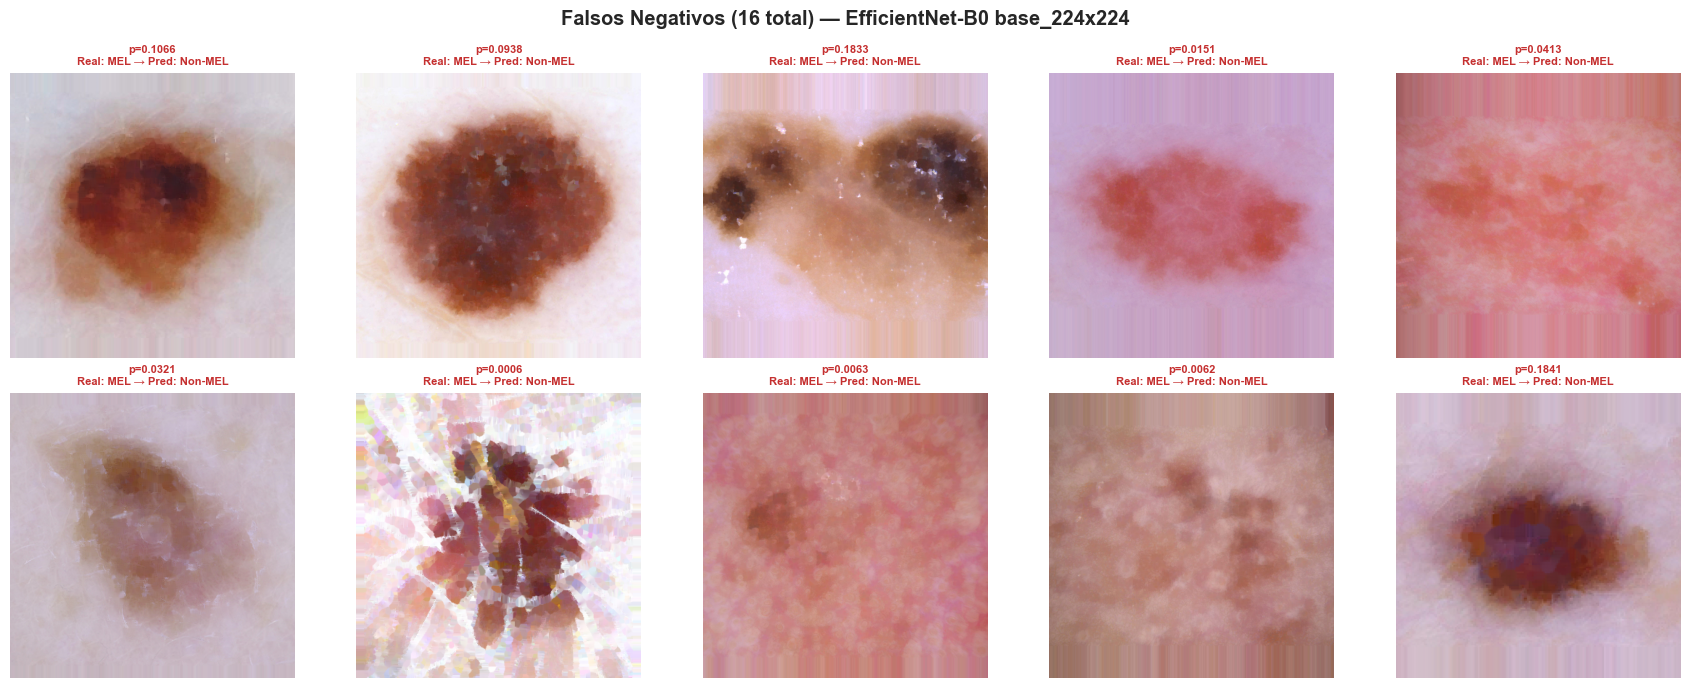

In [68]:
fn_indices = np.where((test_labels == 1) & (test_preds == 0))[0]
print(f"Falsos negativos: {len(fn_indices)} melanomas classificados como não-melanoma")
print(f"  Probabilidades: {sorted(test_probs[fn_indices].tolist())}")

n_show = min(len(fn_indices), 10)
if n_show > 0:
    cols = min(n_show, 5)
    rows_plot = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows_plot, cols, figsize=(3.5 * cols, 3.5 * rows_plot))
    axes = np.array(axes).flatten()

    for i, idx in enumerate(fn_indices[:n_show]):
        record = test_ds.records.iloc[idx]
        img = plt.imread(str(record["export_path"]))
        axes[i].imshow(img)
        axes[i].set_title(
            f"p={test_probs[idx]:.4f}\nReal: MEL → Pred: Non-MEL",
            fontsize=8, color="#c53030", fontweight="bold",
        )
        axes[i].axis("off")

    for j in range(n_show, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        f"Falsos Negativos ({len(fn_indices)} total) — EfficientNet-B0 base_224x224",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / "false_negatives.png", dpi=150, bbox_inches="tight")
    plt.show()

## 12. Falsos positivos — amostra dos mais confiantes

Falsos positivos: 343 não-melanomas classificados como melanoma


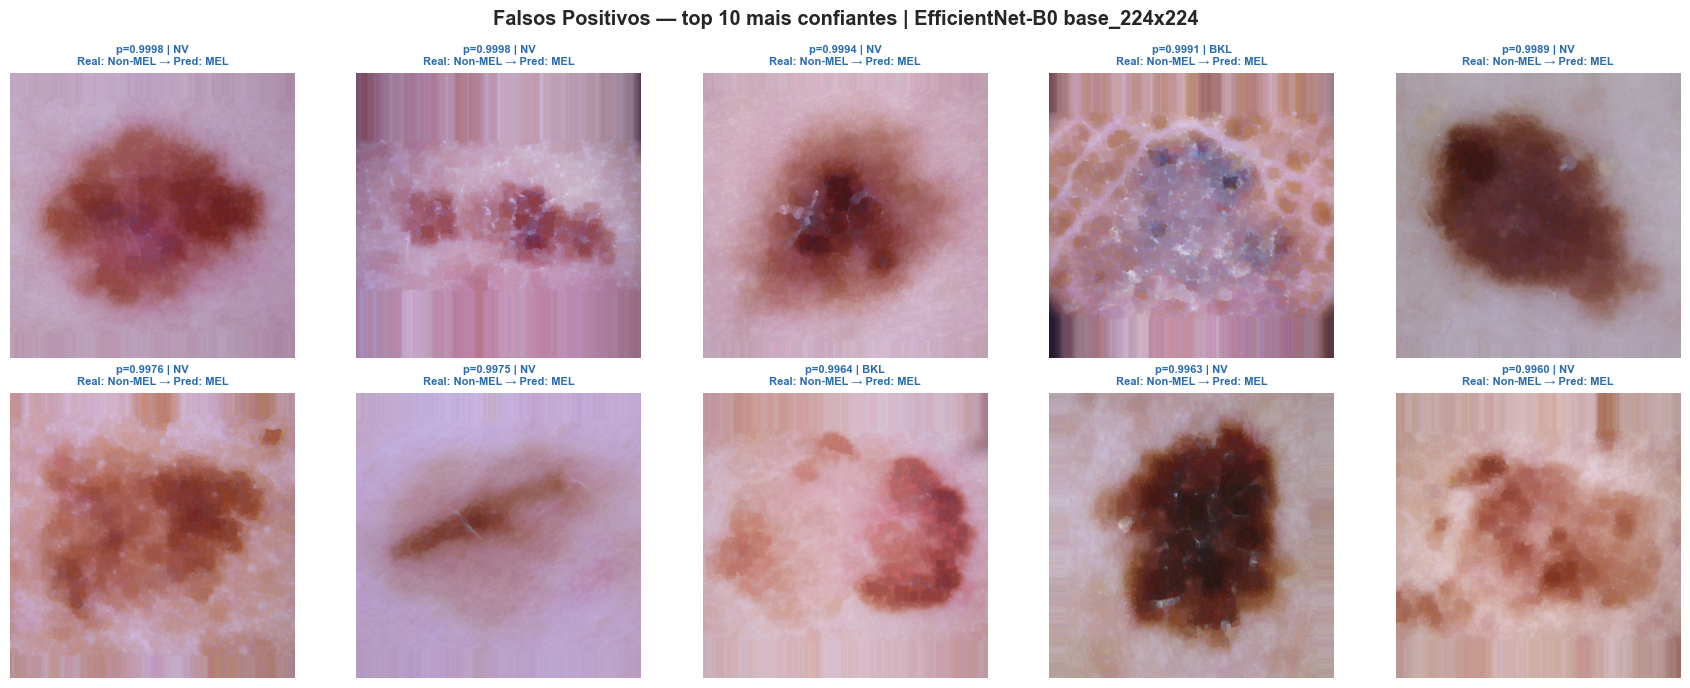

In [69]:
fp_indices = np.where((test_labels == 0) & (test_preds == 1))[0]
fp_sorted  = fp_indices[np.argsort(test_probs[fp_indices])[::-1]]
print(f"Falsos positivos: {len(fp_indices)} não-melanomas classificados como melanoma")

n_show = min(len(fp_sorted), 10)
if n_show > 0:
    cols = min(n_show, 5)
    rows_plot = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows_plot, cols, figsize=(3.5 * cols, 3.5 * rows_plot))
    axes = np.array(axes).flatten()

    for i, idx in enumerate(fp_sorted[:n_show]):
        record = test_ds.records.iloc[idx]
        img = plt.imread(str(record["export_path"]))
        label_name = record.get("label", "N/A") if isinstance(record, dict) else getattr(record, "label", "N/A")
        axes[i].imshow(img)
        axes[i].set_title(
            f"p={test_probs[idx]:.4f} | {label_name}\nReal: Non-MEL → Pred: MEL",
            fontsize=8, color="#2b6cb0", fontweight="bold",
        )
        axes[i].axis("off")

    for j in range(n_show, len(axes)):
        axes[j].axis("off")

    plt.suptitle(
        f"Falsos Positivos — top {n_show} mais confiantes | EfficientNet-B0 base_224x224",
        fontweight="bold",
    )
    plt.tight_layout()
    plt.savefig(FIG_DIR / "false_positives.png", dpi=150, bbox_inches="tight")
    plt.show()

## 14. Classificação em três zonas

Em vez de um único threshold, usamos dois:

- `prob < T_LOW` → **Não melanoma** (zona segura: no máximo 2% dos melanomas reais caem aqui)
- `T_LOW ≤ prob < T_HIGH` → **Possível melanoma** (zona incerta → revisão clínica)
- `prob ≥ T_HIGH` → **Melanoma** (sensibilidade ≥ 95%)

Ambos os thresholds são escolhidos na **validação**.

In [70]:
LOW_FNR_BUDGET   = 0.02   # máx 2% dos melanomas reais abaixo de T_LOW
HIGH_SENS_TARGET = MELANOMA_RECALL_TARGET  # sensibilidade ≥ 95% acima de T_HIGH


def choose_dual_threshold(
    probs: np.ndarray,
    labels: np.ndarray,
    high_sens_target: float = 0.95,
    low_fnr_budget: float = 0.02,
):
    """Escolhe T_LOW e T_HIGH na validação.

    T_HIGH: maior especificidade com sensibilidade >= high_sens_target.
    T_LOW : maior threshold onde melanomas abaixo <= low_fnr_budget do total.
    """
    candidates = np.sort(np.unique(
        np.round(np.concatenate(([0.0], probs, [1.0])), 6)
    ))
    total_mel = max(int(labels.sum()), 1)

    t_high, _, _ = choose_threshold(probs, labels, high_sens_target)

    t_low = 0.0
    for t in candidates:
        if t >= t_high:
            break
        mel_below = int(((probs < t) & (labels == 1)).sum())
        if mel_below / total_mel <= low_fnr_budget:
            t_low = float(t)

    return t_low, t_high


T_LOW, T_HIGH = choose_dual_threshold(
    val_probs, val_labels,
    high_sens_target=HIGH_SENS_TARGET,
    low_fnr_budget=LOW_FNR_BUDGET,
)
print(f"T_LOW  (Não melanoma abaixo de) : {T_LOW:.6f}")
print(f"T_HIGH (Melanoma acima de)       : {T_HIGH:.6f}")
print(f"Zona incerta                     : [{T_LOW:.6f}, {T_HIGH:.6f})")


T_LOW  (Não melanoma abaixo de) : 0.003779
T_HIGH (Melanoma acima de)       : 0.220775
Zona incerta                     : [0.003779, 0.220775)


In [71]:
def classify_three_zone(probs, t_low, t_high):
    return np.where(
        probs >= t_high, "Melanoma",
        np.where(probs < t_low, "Não melanoma", "Possível melanoma"),
    )


zone_preds = classify_three_zone(test_probs, T_LOW, T_HIGH)
zone_df = pd.DataFrame({
    "prob": test_probs,
    "real": np.where(test_labels == 1, "Melanoma", "Não melanoma"),
    "zona": zone_preds,
})

ZONE_ORDER = ["Não melanoma", "Possível melanoma", "Melanoma"]
total_mel_test = int(test_labels.sum())
total_test_n   = len(test_labels)

print(f"{'Zona':<22} {'Total':>7} {'% total':>8} {'Mel reais':>10} {'% dos mels':>12} {'Taxa mel':>10}")
print("-" * 73)
for zona in ZONE_ORDER:
    mask   = zone_preds == zona
    n_tot  = int(mask.sum())
    n_mel  = int(((zone_preds == zona) & (test_labels == 1)).sum())
    pct_t  = n_tot / total_test_n * 100
    pct_m  = n_mel / total_mel_test * 100
    taxa_m = n_mel / n_tot * 100 if n_tot > 0 else 0.0
    print(f"{zona:<22} {n_tot:>7} {pct_t:>7.1f}% {n_mel:>10} {pct_m:>11.1f}% {taxa_m:>9.1f}%")
print("-" * 73)
print(f"{'TOTAL':<22} {total_test_n:>7} {'100.0%':>8} {total_mel_test:>10} {'100.0%':>12}           ")


Zona                     Total  % total  Mel reais   % dos mels   Taxa mel
-------------------------------------------------------------------------
Não melanoma               573    38.1%          1         0.6%       0.2%
Possível melanoma          436    29.0%         15         9.0%       3.4%
Melanoma                   494    32.9%        151        90.4%      30.6%
-------------------------------------------------------------------------
TOTAL                     1503   100.0%        167       100.0%           


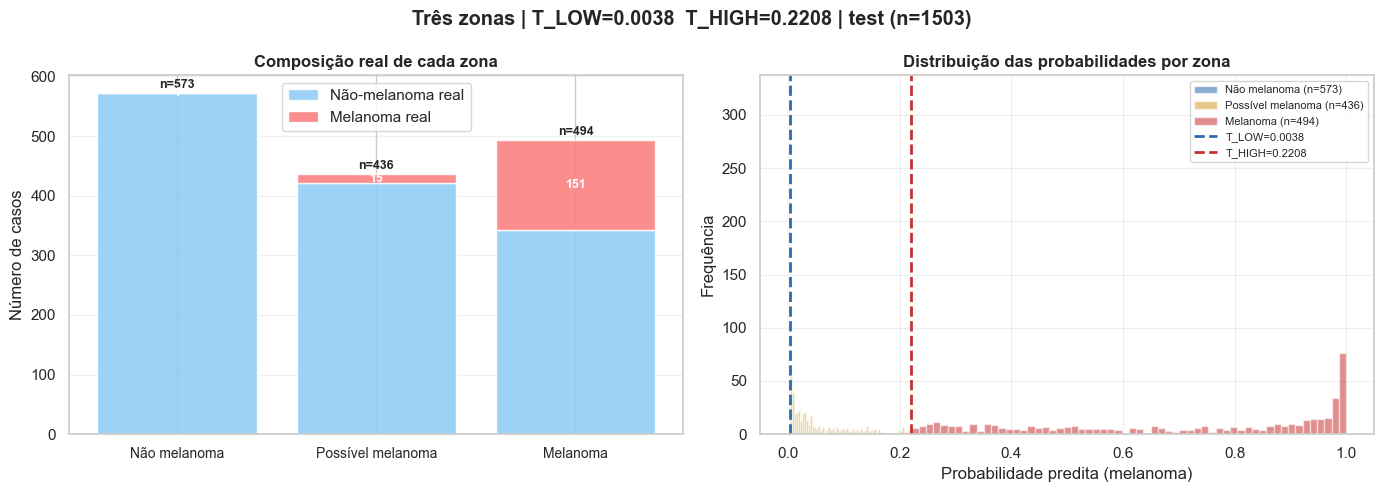

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: stacked bar por zona ---
zone_colors_bar = {
    "Não melanoma":     "#2b6cb0",
    "Possível melanoma": "#d69e2e",
    "Melanoma":          "#c53030",
}
counts_mel   = [int(((zone_preds == z) & (test_labels == 1)).sum()) for z in ZONE_ORDER]
counts_nomel = [int(((zone_preds == z) & (test_labels == 0)).sum()) for z in ZONE_ORDER]
totals_bar   = [m + n for m, n in zip(counts_mel, counts_nomel)]

x = np.arange(len(ZONE_ORDER))
b1 = axes[0].bar(x, counts_nomel, color="#90cdf4", alpha=0.9, label="Não-melanoma real")
b2 = axes[0].bar(x, counts_mel, bottom=counts_nomel, color="#fc8181", alpha=0.9, label="Melanoma real")
axes[0].set_xticks(x)
axes[0].set_xticklabels(ZONE_ORDER, fontsize=10)
axes[0].set_ylabel("Número de casos")
axes[0].set_title("Composição real de cada zona", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")
for i, (tot, nm, m) in enumerate(zip(totals_bar, counts_nomel, counts_mel)):
    axes[0].text(i, tot + 8, f"n={tot}", ha="center", fontsize=9, fontweight="bold")
    if m > 0:
        axes[0].text(i, nm + m / 2, f"{m}", ha="center", va="center",
                     fontsize=9, color="white", fontweight="bold")

# --- Gráfico 2: distribuição de probabilidades por zona ---
for zona in ZONE_ORDER:
    mask = zone_preds == zona
    if mask.sum() > 0:
        axes[1].hist(
            test_probs[mask], bins=60, alpha=0.55,
            color=zone_colors_bar[zona], label=f"{zona} (n={mask.sum()})"
        )
axes[1].axvline(T_LOW,  color="#2b6cb0", linestyle="--", linewidth=2,
                label=f"T_LOW={T_LOW:.4f}")
axes[1].axvline(T_HIGH, color="#c53030", linestyle="--", linewidth=2,
                label=f"T_HIGH={T_HIGH:.4f}")
axes[1].set_xlabel("Probabilidade predita (melanoma)")
axes[1].set_ylabel("Frequência")
axes[1].set_title("Distribuição das probabilidades por zona", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle(
    f"Três zonas | T_LOW={T_LOW:.4f}  T_HIGH={T_HIGH:.4f} | test (n={total_test_n})",
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(FIG_DIR / "three_zone_classification.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Resumo executivo

In [73]:
summary_data = {
    "modelo": "EfficientNet-B0",
    "experimento": "base_224x224",
    "threshold": round(THRESHOLD, 6),
    "auc": round(auc_test, 4),
    "sensibilidade": round(sensitivity, 4),
    "especificidade": round(specificity, 4),
    "precisao": round(precision, 4),
    "f1": round(f1, 4),
    "f2": round(f2, 4),
    "acuracia": round(accuracy, 4),
    "tp": int(tp),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "total_test": total,
    "melanomas_reais": n_mel,
    "nao_melanomas_reais": n_nonmel,
    "preditos_como_melanoma": pred_mel,
    "preditos_como_nao_melanoma": pred_nonmel,
}

display(pd.DataFrame([summary_data]).T.rename(columns={0: "Valor"}))

with open(FIG_DIR / "summary.json", "w") as f:
    json.dump(summary_data, f, indent=2, ensure_ascii=False)

print(f"\nFiguras salvas em : {FIG_DIR}")
print(f"Resumo JSON em    : {FIG_DIR / 'summary.json'}")

,Valor
modelo,EfficientNet-B0
experimento,base_224x224
threshold,0.220775
auc,0.9015
sensibilidade,0.9042
especificidade,0.7433
precisao,0.3057
f1,0.4569
f2,0.6497
acuracia,0.7611



Figuras salvas em : /Users/eduardoyaginuma/Documents/Repositorios/insper/skin-cancer-images-segmentation/outputs/figures/modeling_2
Resumo JSON em    : /Users/eduardoyaginuma/Documents/Repositorios/insper/skin-cancer-images-segmentation/outputs/figures/modeling_2/summary.json
